# Composition analysis

Given the organoid graphs, curvature predictions can depends on multiple sources of information. A useful decomposition is:

\begin{equation}
\mathbb{E}[\kappa_i \mid \text{data}] \approx
\underbrace{f_{\text{structure}}}_{\text{packing / positional context}}
+
\underbrace{f_{\text{center marker}}}_{\text{cell identity}}
+
\underbrace{f_{\text{neighborhood markers}}}_{\text{local composition}}
+
\epsilon.
\end{equation}

Similarly, predictive uncertainty may depend on:

\begin{equation}
\mathrm{Var}(\kappa_i \mid \text{data}) \approx
g_{\text{composition ambiguity}} +
g_{\text{structural heterogeneity}}.
\end{equation}


These experiments probe which parts of the local tissue context drive curvature prediction.

We compare three model families:
- **GIN**: a message-passing GNN that can, in principle, exploit fine neighborhood arrangement.
- **Ring-fraction MLP**: uses marker fractions in exact hop rings and therefore retains coarse radial composition.
- **Ring-size MLP**: uses only ring sizes (local graph structure / packing) together with the center-cell identity.

The overall goal is to separate the roles of:
1. **center-cell identity**,
2. **neighborhood marker composition**, and
3. **coarse local structure / packing**.

Excellent idea 👍 — having a **single experimental overview block** will make the notebook (and later a paper / talk) much easier to follow.

Here is a clean, compact version you can paste near the top.

---

## Experimental overview: probing the role of neighborhood composition

We study how much information about local membrane curvature is carried by **cell fate markers and their spatial organization** in intestinal organoid graphs.

Models are always **trained on the original organoid graphs**.
Differences between experiments arise only from how neighborhood marker structure is perturbed during **evaluation**.

We compare three evaluation conditions:

### Experiment 1 — Original neighborhood structure

Models are evaluated on ego-subgraphs built from the unmodified validation organoids.

This represents the full biological signal:

* center marker identity,
* neighborhood marker composition,
* fine spatial organization of cells.

Performance here defines the **reference level** for all comparisons.

---

### Experiment 2 — Center-preserving neighborhood permutation

Marker features are randomly permuted within each organoid, destroying spatial correlations between neighboring cell types.
Ego-subgraphs are then rebuilt around sampled centers, with the **center marker restored to its original value**.

This removes information about **which markers surround a cell**, while keeping:

* center marker identity,
* curvature targets,
* global marker frequencies.

Performance degradation relative to Experiment 1 quantifies the contribution of **informative neighborhood composition**.

---

### Experiment 3 — Ring-preserving permutation

Marker features are permuted **only within each k-hop ring**, preserving how many cells of each type occur at each distance scale but destroying finer spatial ordering.

This keeps **coarse multi-scale composition** intact while removing **fine spatial structure** such as clustering or directional organization.

Comparing performance across Experiments 1–3 allows us to disentangle the roles of:

* center marker identity
* coarse neighborhood composition
* fine spatial arrangement and topology

in predicting local curvature.

---

### Model comparison

We evaluate multiple model families with different spatial expressivity:

* Graph neural networks (message passing with topology awareness)
* Ring-based MLP models (composition-only representations)
* Pooled variants capturing cumulative multi-hop statistics

Performance trends across depth and perturbation conditions help determine **which spatial scales and representations carry predictive biological signal**.



## Setup and training

### Specify model and training parameters

In [28]:
import numpy as np
import matplotlib.pyplot as plt

K_MAX = 9

base_hidden_dim = 2*64
base_dropout = 0.1
base_norm = "batch"

lr = 1e-3
batch_size = 128
max_epochs = 500
patience = 100

trained_model_families = {
    "GIN": [],
    "ring-fraction": [],
    "ring-size": [],
}

depths = np.arange(0, K_MAX)

### Load and process data

In [29]:
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [30]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [31]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [32]:
from src.data.preprocessing import subtract_organoid_mean_curvature

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)

In [33]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

center, scale = standardize_graph_targets(g_train, g_val, robust=True)

Split -> train: 705 | val: 176


In [34]:
from src.data.ring_features import attach_precomputed_ring_features

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

### Train models on organoid graphs

In [35]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    patience=patience,
    num_workers=4,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, RingSizeMLP

for family in trained_model_families.keys():

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        n_markers = int(g_train[0].x.size(1))

        if family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
            }
            model = GINCurvature(**model_kwargs)

        elif family == "ring-fraction":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "ring-size":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
            }
            model = RingSizeMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")


        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_model_families[family].append(model)


=== Training GIN model with depth=0 ===
epoch 001 | train loss 1.3612 mae 1.0102 | val loss 1.4770 mae 0.9949
epoch 002 | train loss 1.2174 mae 1.0037 | val loss 1.3267 mae 0.9886
epoch 003 | train loss 1.1168 mae 0.9980 | val loss 1.2154 mae 0.9830
epoch 004 | train loss 1.0365 mae 0.9924 | val loss 1.1375 mae 0.9782
epoch 005 | train loss 0.9888 mae 0.9870 | val loss 1.0792 mae 0.9738
epoch 006 | train loss 0.9534 mae 0.9828 | val loss 1.0377 mae 0.9704
epoch 007 | train loss 0.9261 mae 0.9789 | val loss 1.0087 mae 0.9683
epoch 008 | train loss 0.9059 mae 0.9768 | val loss 0.9884 mae 0.9676
epoch 009 | train loss 0.8922 mae 0.9759 | val loss 0.9718 mae 0.9683
epoch 010 | train loss 0.8818 mae 0.9762 | val loss 0.9596 mae 0.9695
epoch 011 | train loss 0.8727 mae 0.9769 | val loss 0.9504 mae 0.9713
epoch 012 | train loss 0.8663 mae 0.9782 | val loss 0.9431 mae 0.9734
epoch 013 | train loss 0.8603 mae 0.9789 | val loss 0.9378 mae 0.9745
epoch 014 | train loss 0.8554 mae 0.9794 | val lo

KeyboardInterrupt: 

## Prepare validation data for experiments

Note, for **ego-subgraph evaluation**, we do **not** try to transfer precompute exact-ring marker fractions to the subgraphs. Instead, the ring-based models recompute features on the ego-subgraphs on the fly.

This is fine here because:
- the subgraphs are built with radius `K_MAX`,
- we evaluate **only the center node** of each subgraph,
- therefore the center node has access to its full $k \leq K_{MAX}$ neighborhood inside the subgraph.

So the center-node ring features computed on the subgraph are exact, even if boundary nodes inside the subgraph would not have exact full-graph ring features.

In [ ]:
from src.data.subgraphs import build_ego_subgraphs_for_dataset 

val_subgraphs  = build_ego_subgraphs_for_dataset(
    g_val,
    num_hops=K_MAX,
    max_centers_per_graph=None, 
    seed=0,
)

From all the subgraphs in the validation set, we sample to have coverage of all marker combinations

In [ ]:
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary

sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
    val_subgraphs,
    marker_names=marker_names,
    k_hops=K_MAX,          # or the k_hops you will perturb over
    max_subgraphs=5000,          # your budget
    min_center_count=40,
    min_pair_count=25,
    seed=0,
)

print_sampling_summary(sample_info, marker_names)

Selected 2000 / 72093 subgraphs

Center coverage:
LGR5          covered= 420  target=  40  available=11945  OK
Chroma        covered=  89  target=  40  available= 280  OK
AldoB         covered= 791  target=  40  available=28703  OK
Agr2          covered= 175  target=  40  available=3561  OK
Serotonin     covered=  75  target=  40  available= 249  OK
Lysozyme      covered= 116  target=  40  available=1875  OK
KI67          covered= 673  target=  40  available=22066  OK

Unsatisfied center markers: []
Unsatisfied pair features: 1


### Setup helper functions for analysis

In [ ]:
from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, scale, center):
    all_results = {}

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        for model in models:
            model.eval()
            out = eval_model_per_marker(model, eval_subgraphs, device, scale, center, center_only=True)

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
        }

    return all_results




## Experiment 1: Original organoid graphs

This establishes the baseline behavior of each model family when trained on the original full graphs and evaluated on the same sampled validation centers.

Because we evaluate only the **center node** of each ego-subgraph, the sampled validation set gives us:
- good control over rare center markers,
- much cheaper evaluation than using every node in every organoid,
- direct markerwise comparison against the baseline mean curvature per center marker.


In [ ]:
all_results_exp1 = evaluate_family_models(
    trained_models=trained_model_families,
    eval_subgraphs=sampled_val_subgraphs,
    device=device,
    scale=scale,
    center=center,
)

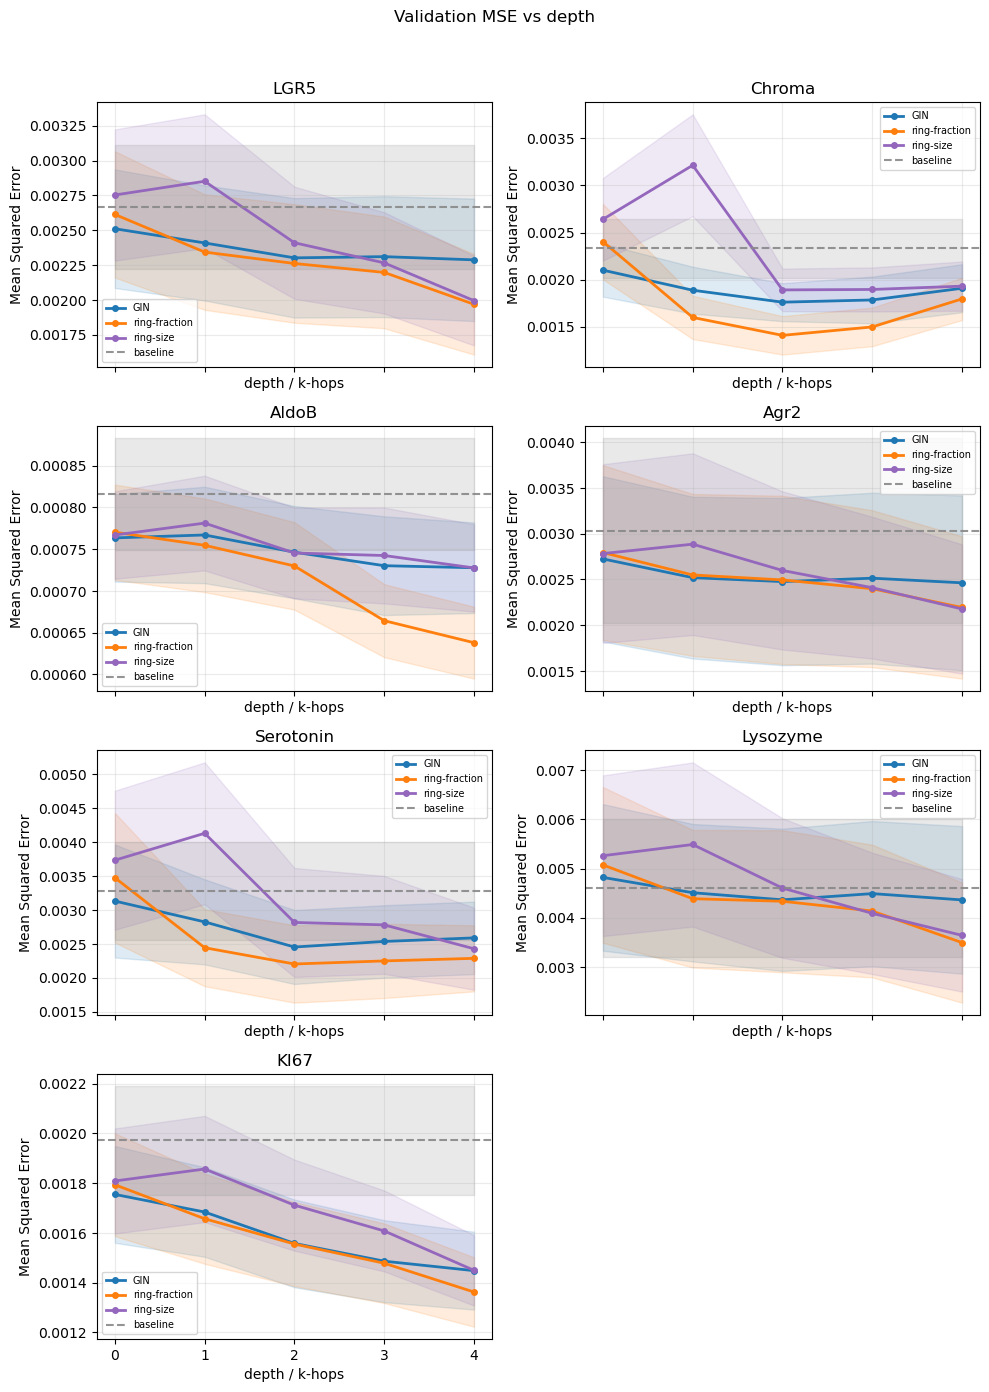

In [ ]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth
plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GIN":          "#1f77b4",
    "ring-fraction":"#ff7f0e",
    "ring-size":    "#9467bd",
}

family_order = [
    "GIN",
    "ring-fraction",
    "ring-size",
]


plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=depths,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

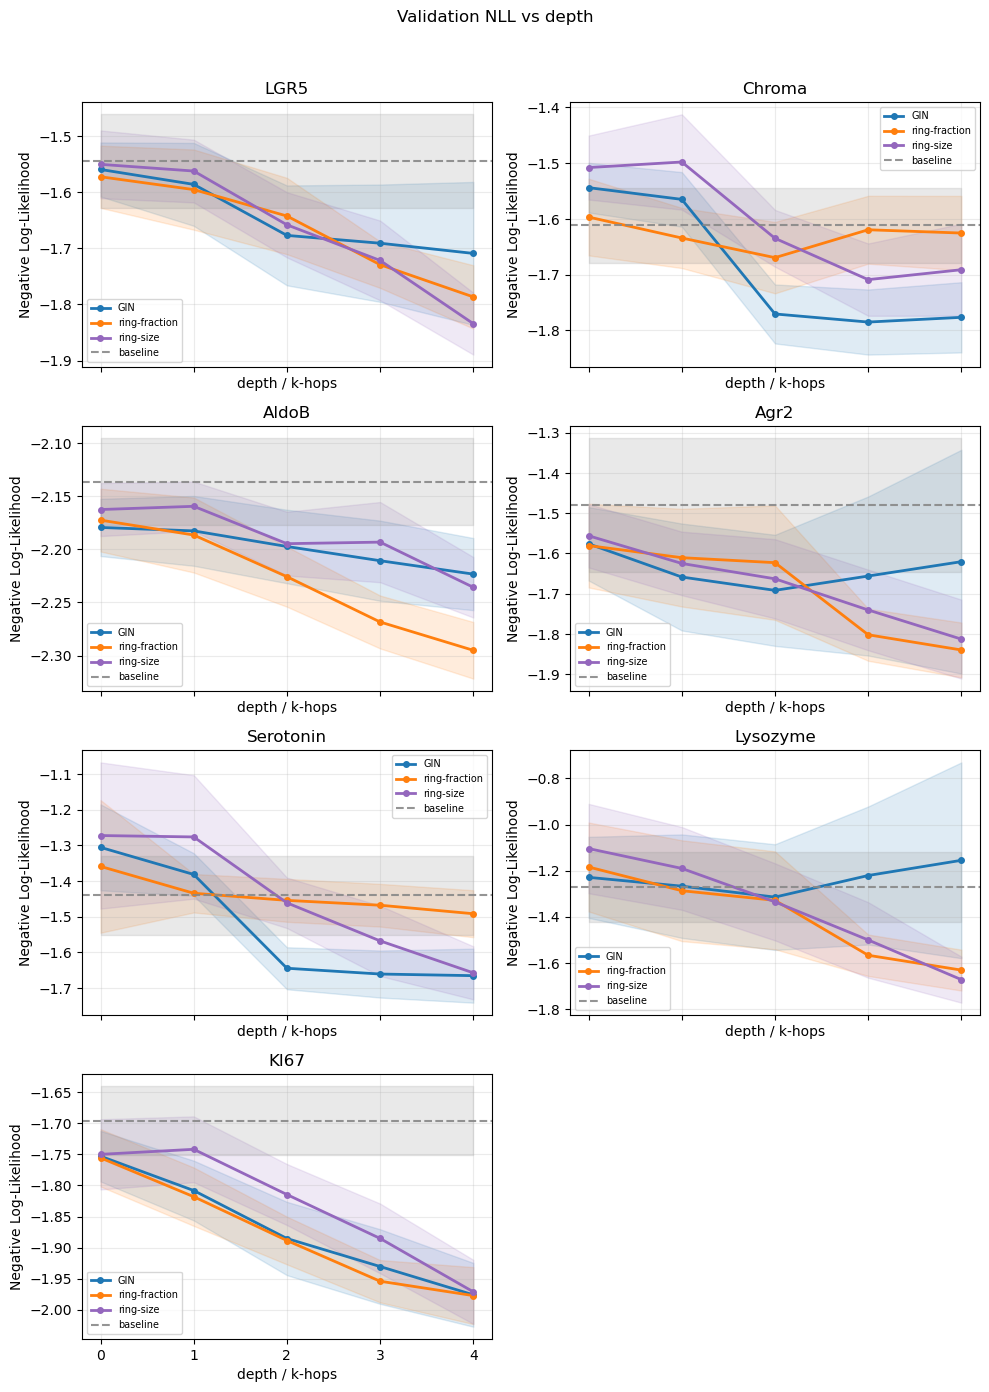

In [ ]:
plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=depths,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

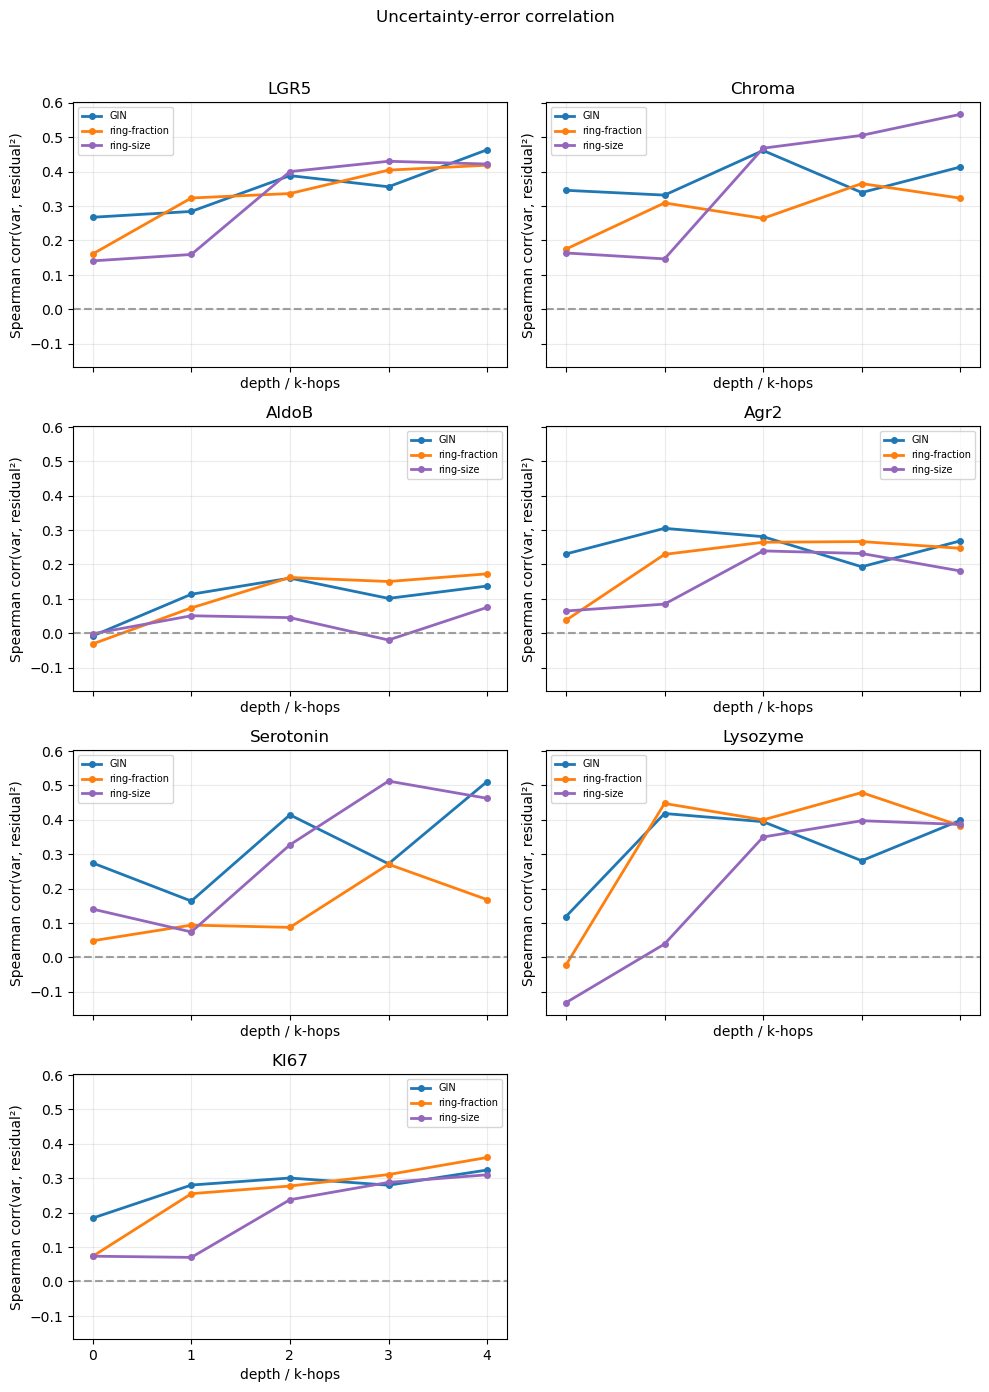

In [ ]:

plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=depths,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
plt.show()


## Experiment 2: Center-preserving neighborhood permutation (evaluation-time ablation)

In this experiment we **reuse the models trained on the original organoid graphs** and evaluate them under controlled perturbations of neighborhood marker composition.

The goal is to test how much predictive signal comes from **neighborhood organization**, beyond what is already explained by the **identity of the center cell**.

### Procedure

1. We first sample a fixed set of validation centers (balanced across markers).
   These centers are reused in all evaluation conditions to ensure fair markerwise comparisons.

2. Marker feature rows are then **randomly permuted within each validation organoid**.
   This destroys spatial correlations between marker identity and curvature while preserving:

   * global marker frequencies,
   * graph topology,
   * organoid-level composition.

3. Ego-subgraphs are rebuilt around the sampled centers.
   For each subgraph, the **center marker row is restored to its original value**, while all neighborhood markers remain permuted.

### Interpretation

This intervention removes information about **which markers surround a given cell**, while keeping the center marker and curvature target unchanged.

Any degradation in performance relative to evaluation on original subgraphs therefore reflects the model’s reliance on **informative neighborhood composition**.

This differs from training on permuted graphs, which would destroy both center-marker and neighborhood-marker alignment and would act as a much stronger (and less interpretable) null model.

### What to monitor in the analysis

* Markerwise changes in MSE / NLL relative to baseline
* Dependence of performance drop on model depth
* Differences between model families (GNN vs ring models)
* Behaviour of predicted variance under permutation
* Whether performance approaches the marker-conditional baseline

These observations help disentangle how much curvature information is encoded in **center identity vs spatial marker organization**.



In [ ]:
from src.data.permutation import permute_graph_features_within_organoid, build_center_preserving_permuted_subgraphs

# Permute full training graphs and recompute ring features on the permuted graphs.
g_train_perm = permute_graph_features_within_organoid(g_train, inplace=False)

# Build center-preserving permuted validation ego-subgraphs for exactly the same sampled centers.
perm_val_subgraphs = build_center_preserving_permuted_subgraphs(
    graphs=g_val,
    sampled_subgraphs=sampled_val_subgraphs,
    num_hops=K_MAX,
    permute_graphs_fn=permute_graph_features_within_organoid,
    seed=0,
)

print(f"Permuted training graphs: {len(g_train_perm)}")
print(f"Center-preserving permuted validation subgraphs: {len(perm_val_subgraphs)}")


Permuted training graphs: 705
Center-preserving permuted validation subgraphs: 2000


In [ ]:
all_results_exp2 = evaluate_family_models(
    trained_models=trained_model_families,
    eval_subgraphs=perm_val_subgraphs,
    device=device,
    scale=scale,
    center=center,
)

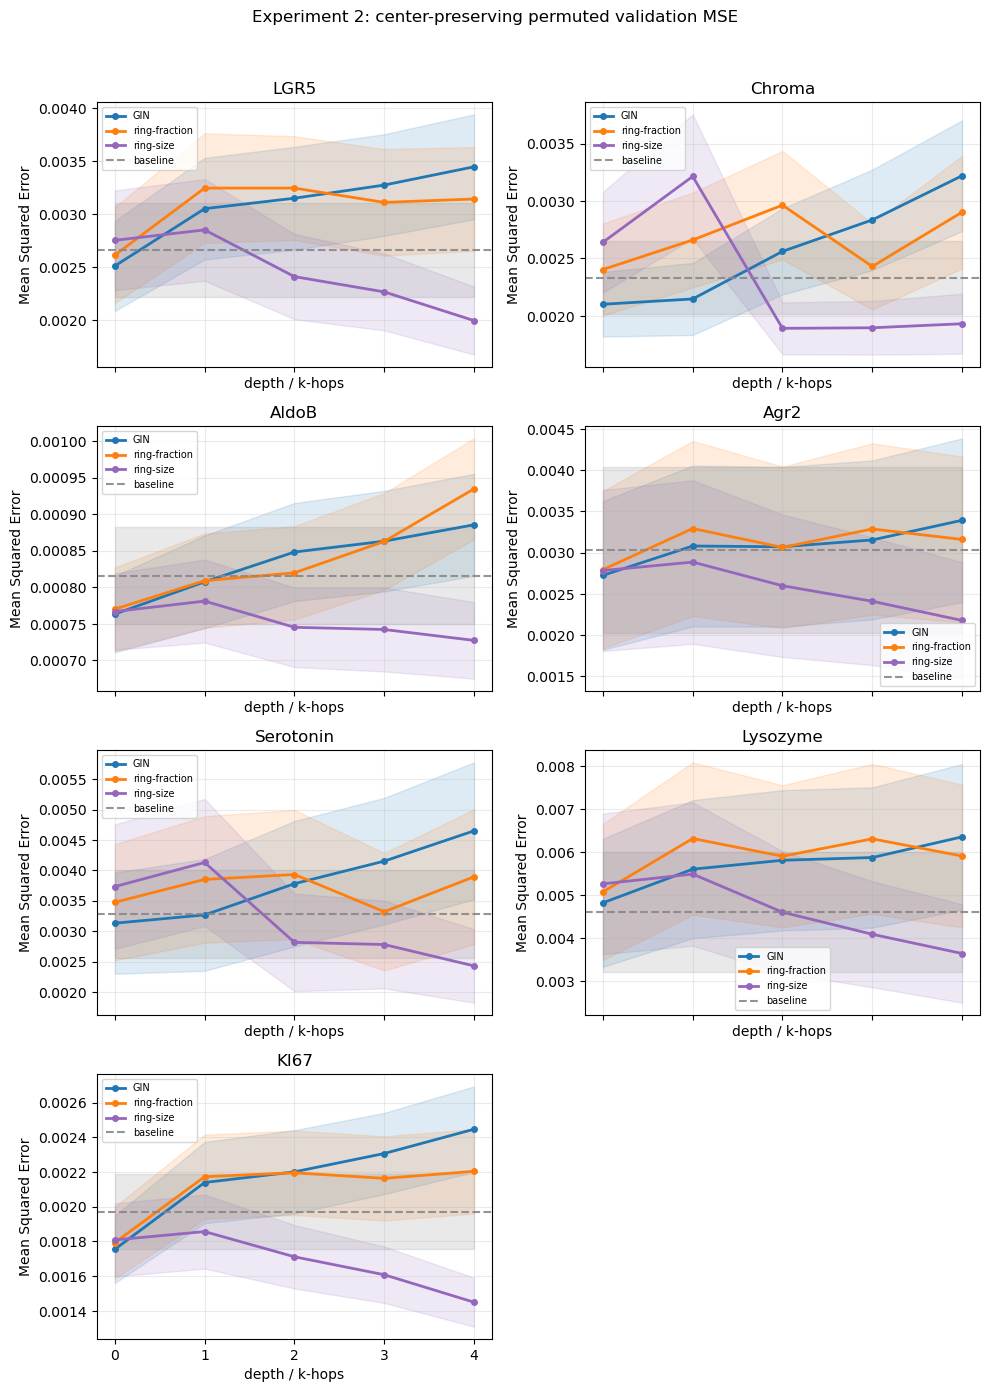

In [ ]:
plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=depths,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Experiment 2: center-preserving permuted validation MSE",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

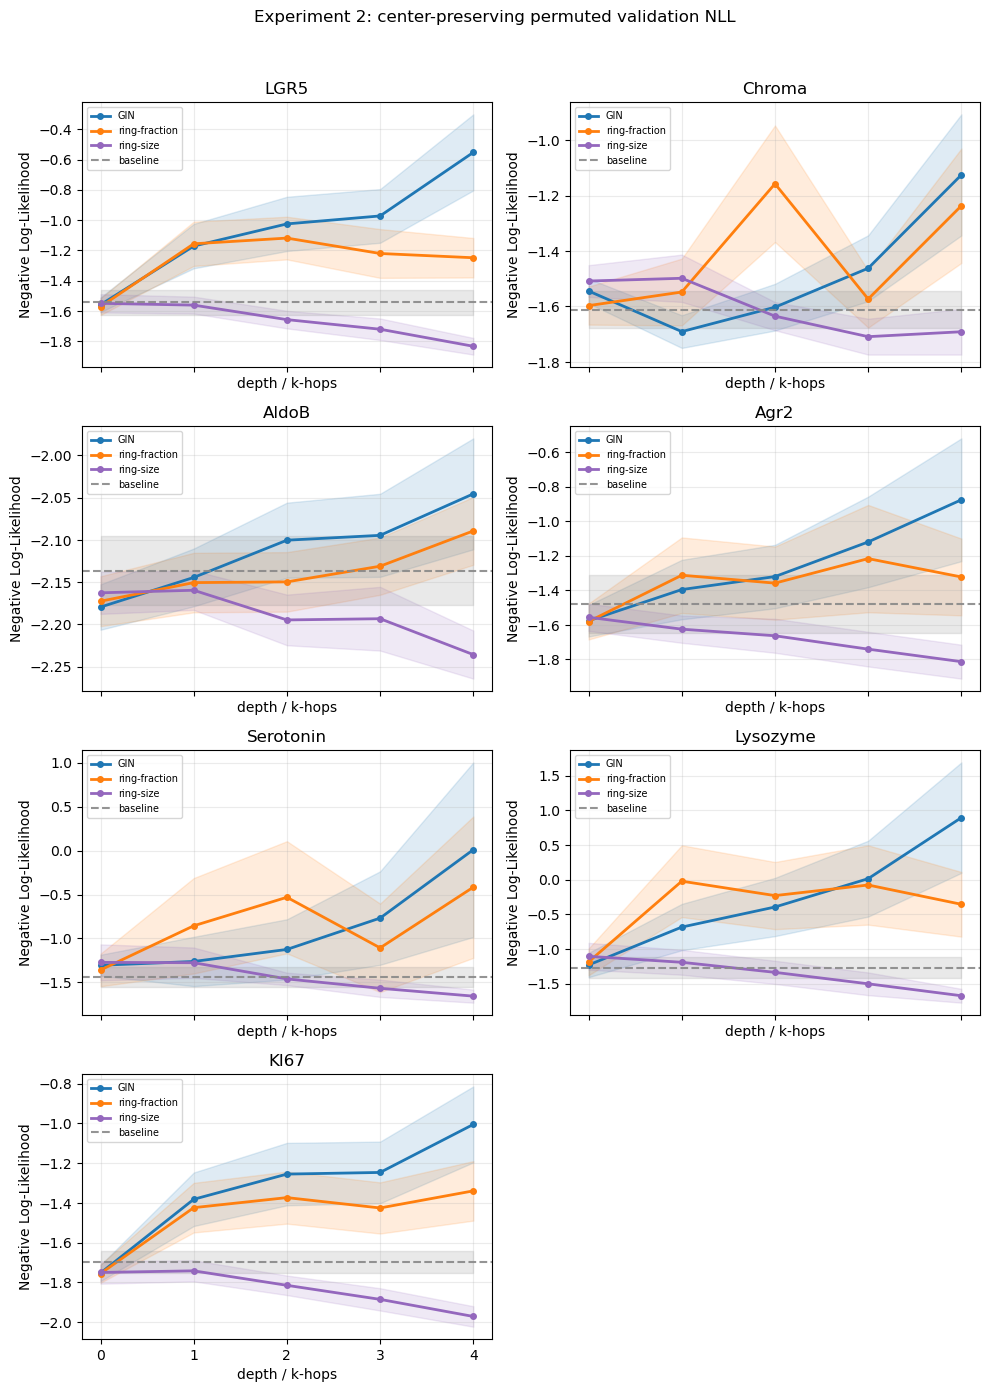

In [ ]:

plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=depths,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Experiment 2: center-preserving permuted validation NLL",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

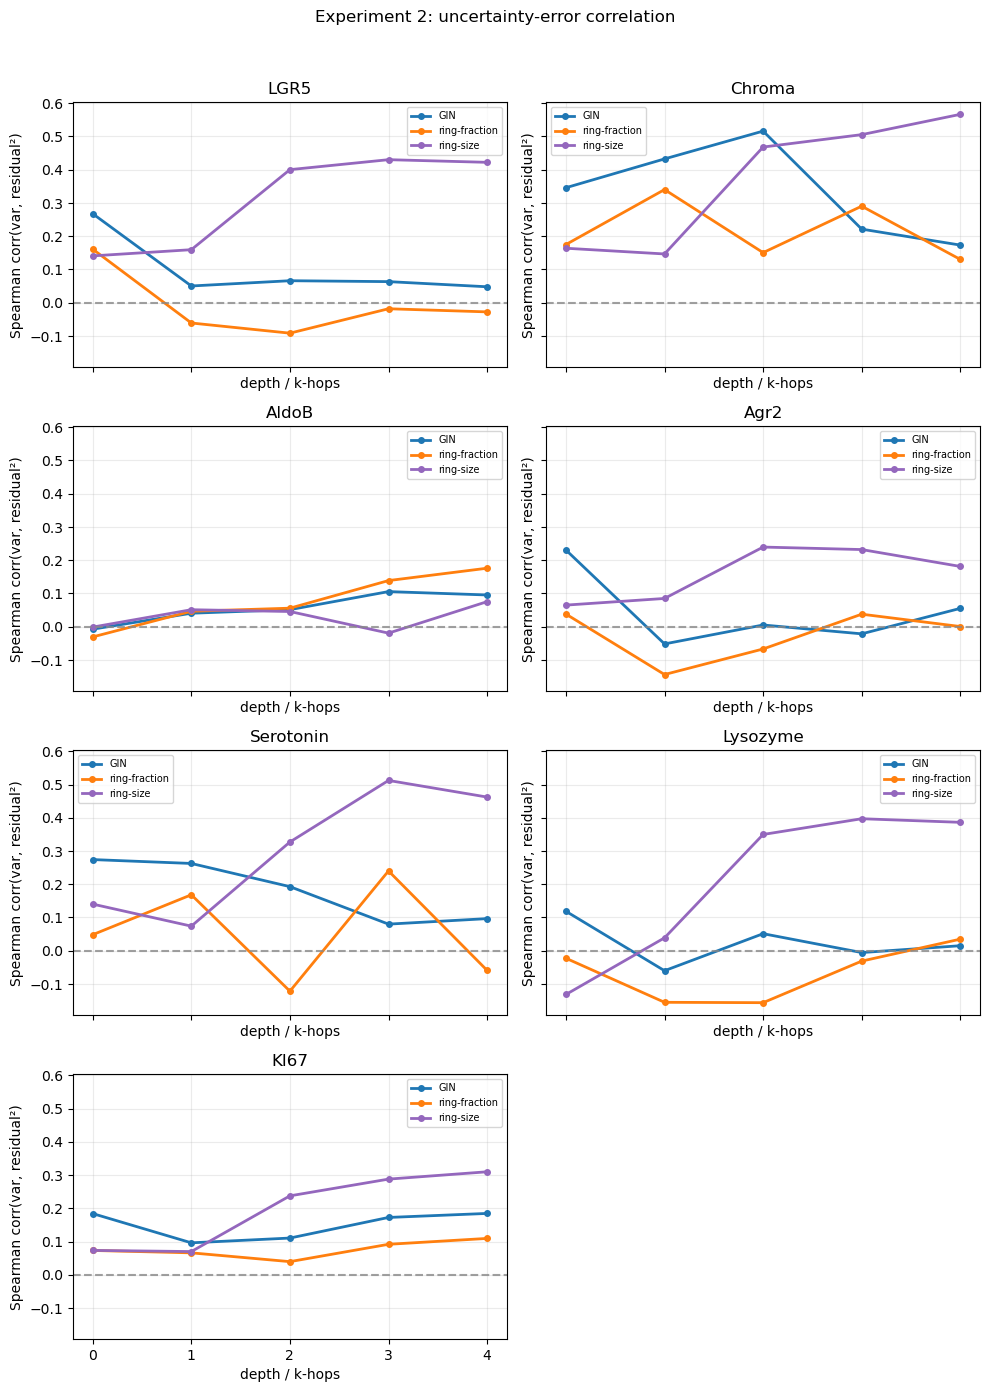

In [ ]:
plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=depths,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 2: uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
plt.show()

## Experiment 3: Ring-preserving permutation (coarse vs fine neighborhood structure)

In this experiment we again **reuse the models trained on the original organoid graphs**, but evaluate them under a milder perturbation of neighborhood marker organization.

The goal is to distinguish whether predictive signal comes primarily from:

* the **coarse composition of markers at different spatial scales**, or
* the **finer spatial arrangement and topology of cells within those scales**.

### Procedure

1. As in Experiment 2, we use the same fixed set of sampled validation centers to ensure fair markerwise comparisons.

2. Within each validation organoid, marker features are **permuted only within each k-hop ring** around every node.
   This preserves:

   * how many cells of each marker type occur in each hop shell,
   * overall organoid composition,
   * graph connectivity.

   However, it destroys:

   * the detailed spatial ordering of cells inside each ring,
   * local clustering patterns,
   * directional gradients and niche geometry.

3. Ego-subgraphs are rebuilt around the sampled centers and evaluated in the same way as before.

### Interpretation

Compared to full neighborhood permutation (Experiment 2), this intervention removes only **fine spatial structure** while keeping **ring-level composition intact**.

Therefore:

* If performance drops strongly relative to the original graphs,
  the model relies on **finer spatial organization or topology**.

* If performance remains similar,
  most predictive signal is already captured by **coarse marker composition at different distances**.

Comparing the sensitivity of different model families (e.g. GNN vs ring-based models) helps clarify whether additional spatial expressivity translates into improved biological signal extraction.

### What to monitor in the analysis

* Markerwise performance changes relative to both:

  * original evaluation
  * fully permuted neighborhoods (Experiment 2)

* Depth dependence of the performance gap

* Differences between GNN and ring-based models

* Behaviour of predicted variance and uncertainty calibration

Together, these comparisons help quantify how curvature prediction depends on **multi-scale neighborhood composition versus fine spatial arrangement**.



In [ ]:
from src.data.permutation import permute_ego_neighborhood_within_rings

ring_permuted_val_subgraphs = permute_ego_neighborhood_within_rings(
    sampled_val_subgraphs,
    k_hops=K_MAX,
)


In [ ]:

all_results_exp3_gin = evaluate_family_models(
    trained_models={"GIN": trained_model_families["GIN"]},
    eval_subgraphs=ring_permuted_val_subgraphs,
    device=device,
    scale=scale,
    center=center,
)


In [ ]:
import math 

def plot_two_result_sets_one_family(results_a, results_b, family, metric_key, sem_key=None, baseline_key=None,
                                    baseline_sem_key=None, ylabel="", title="", label_a="original",
                                    label_b="ring-permuted", color_a="#1f77b4", color_b="#d62728"):
    n_markers = len(marker_names)
    n_cols = 2
    n_rows = math.ceil(n_markers / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.2 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, mi, mname in zip(axes, range(n_markers), marker_names):
        y_a = results_a[family][metric_key][:, mi]
        y_b = results_b[family][metric_key][:, mi]

        ax.plot(depths, y_a, "-o", color=color_a, linewidth=2, markersize=4, label=label_a)
        ax.plot(depths, y_b, "-o", color=color_b, linewidth=2, markersize=4, label=label_b)

        if sem_key is not None:
            s_a = results_a[family][sem_key][:, mi]
            s_b = results_b[family][sem_key][:, mi]
            ax.fill_between(depths, y_a - s_a, y_a + s_a, color=color_a, alpha=0.15)
            ax.fill_between(depths, y_b - s_b, y_b + s_b, color=color_b, alpha=0.15)

        if baseline_key is not None:
            y0 = results_a[family][baseline_key][mi]
            ax.axhline(y0, linestyle="--", color="#888888", alpha=0.8, label="baseline")
            if baseline_sem_key is not None:
                s0 = results_a[family][baseline_sem_key][mi]
                ax.fill_between(depths, y0 - s0, y0 + s0, color="#888888", alpha=0.12)

        ax.set_title(mname)
        ax.set_xlabel("depth / k-hops")
        ax.set_ylabel(ylabel)
        ax.set_xticks(depths)
        ax.legend(fontsize=7)

    for ax in axes[n_markers:]:
        ax.set_visible(False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig

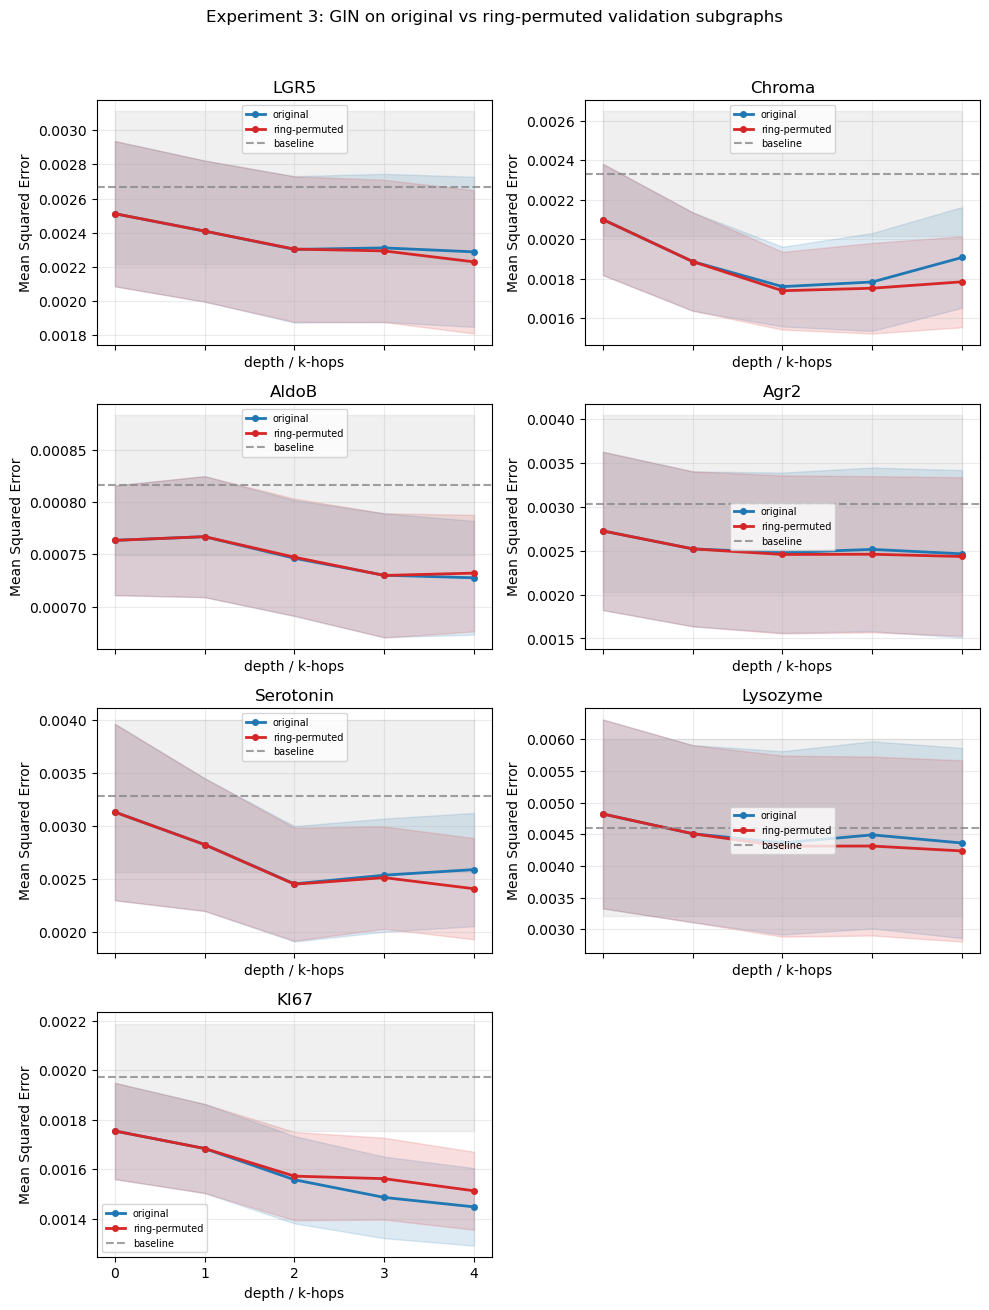

In [ ]:

plot_two_result_sets_one_family(
    all_results_exp1,
    all_results_exp3_gin,
    family="GIN",
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Experiment 3: GIN on original vs ring-permuted validation subgraphs",
)
plt.show()


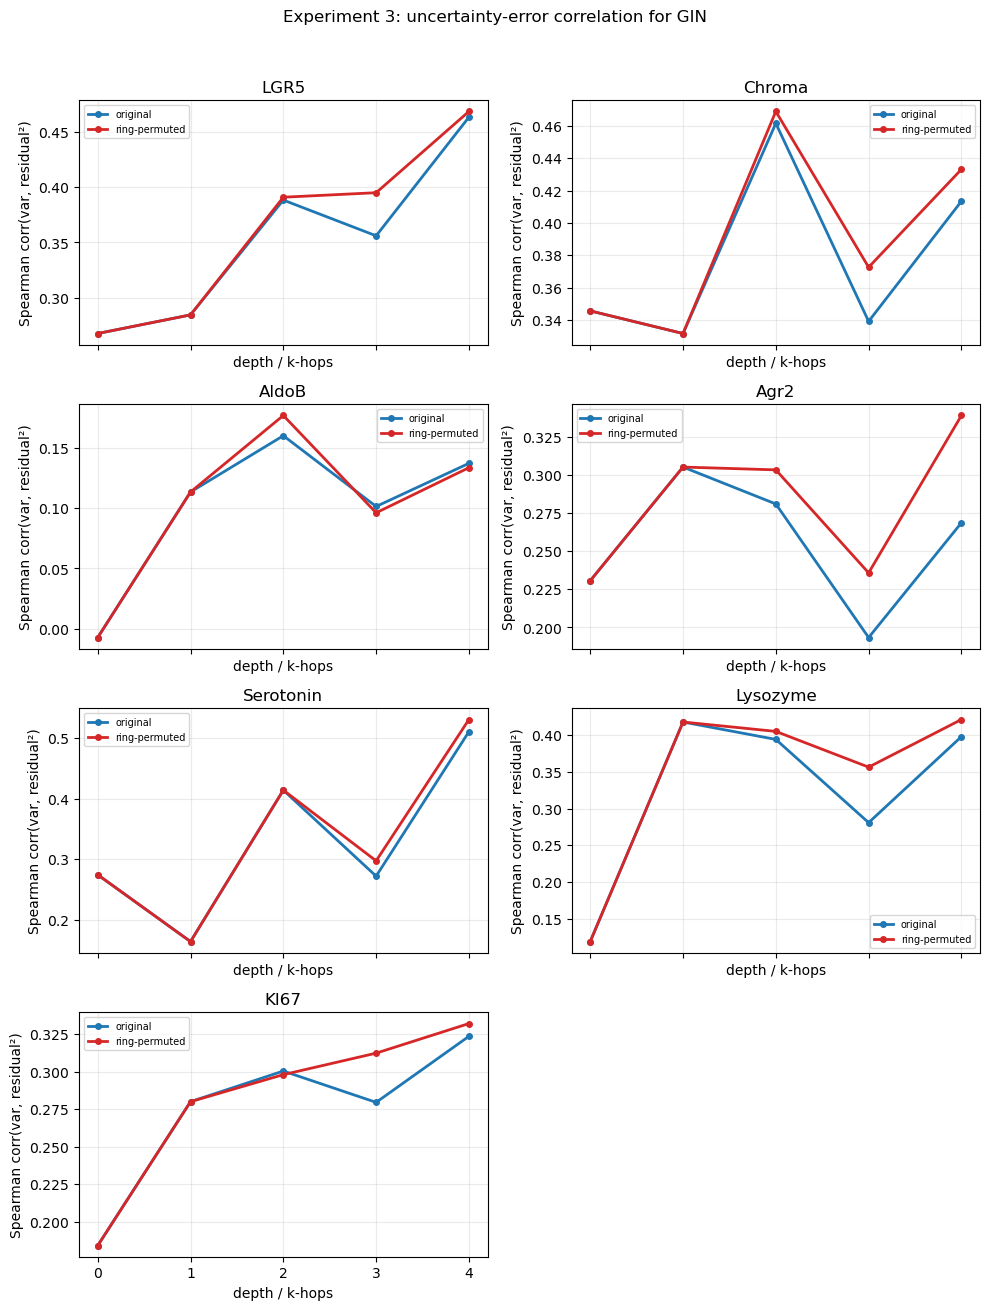

In [ ]:

plot_two_result_sets_one_family(
    all_results_exp1,
    all_results_exp3_gin,
    family="GIN",
    metric_key="rho_marker",
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 3: uncertainty-error correlation for GIN",
)
plt.show()
